# Example 1: Symbolic Regressor

In [1]:
import sys
import os
from pathlib import Path
# Add the parent folder (my_project) to Python's search path
sys.path.append(str(Path.cwd().parent))

%matplotlib inline
from gplearn.genetic_standard import SymbolicRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.random import check_random_state
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import graphviz
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import math
from collections import defaultdict
import graphviz

os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

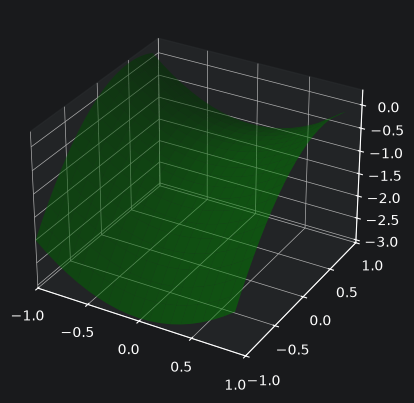

In [2]:
# Ground truth
x0 = np.arange(-1, 1, .1)
x1 = np.arange(-1, 1, .1)
x0, x1 = np.meshgrid(x0, x1)
y_truth = x0**2 - x1**2 + x1 - 1

ax = plt.figure().add_subplot(projection='3d')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xticks(np.arange(-1, 1.01, .5))
ax.set_yticks(np.arange(-1, 1.01, .5))
surf = ax.plot_surface(x0, x1, y_truth, rstride=1, cstride=1, color='green', alpha=0.5)
plt.show()

In [3]:
rng = check_random_state(0)

# Training samples
X_train = rng.uniform(-1, 1, 100).reshape(50, 2)
y_train = X_train[:, 0]**2 - X_train[:, 1]**2 + X_train[:, 1] - 1

# Testing samples
X_test = rng.uniform(-1, 1, 100).reshape(50, 2)
y_test = X_test[:, 0]**2 - X_test[:, 1]**2 + X_test[:, 1] - 1

In [4]:
# est_gp = SymbolicRegressor(population_size=500,
#                            generations=50, stopping_criteria=0.01,
#                            p_crossover=0.7, p_subtree_mutation=0.1,
#                            p_hoist_mutation=0.05, p_point_mutation=0.1,
#                            max_samples=0.9, verbose=1,
#                            parsimony_coefficient=0.01, random_state=0)
# est_gp.fit(X_train, y_train)

In [5]:
def get_benchmark_dataset(name, n_train=100, n_test=100, random_state=0):
    """
    Generates train and test datasets for standard Genetic Programming benchmarks.

    Parameters:
        name (str): Benchmark problem ('E1', 'E2', 'M1', 'M2', 'H1', 'H2')
        n_train (int): Number of training samples
        n_test (int): Number of testing samples
        random_state (int/RandomState): Seed for reproducibility

    Returns:
        X_train, y_train, X_test, y_test
    """
    rng = check_random_state(random_state)
    name = name.upper().replace("-", "").replace("_", "")

    def _generate_data(n_samples):

        # 1. Custom Domain Handling
        if name == 'NGUYEN7':
            # Sampling x from [0, 2] to prevent log(x + 1) domain errors (x <= -1)
            X = rng.uniform(0, 2, n_samples * 5).reshape(-1, 5)
        elif name == 'KEIJZER6':
            # Sampling positive values [1, 100] for harmonic number calculations
            X = rng.uniform(1, 100, n_samples * 5).reshape(-1, 5)
        else:
            # Default standard domain [-5, 5]
            X = rng.uniform(-5, 5, n_samples * 5).reshape(-1, 5)

        x1, x2, x3, x4, x5 = X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4]

        # Define Function

        if name == 'F1':
            y = (x1 + 1) * (x2 +2) * (x3 +3) * (x4 +4) * (x5 +5)
        elif name == 'F2':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4)) + (1 / (1 + x3**-4)) + (1 / (1 + x4**-4)) + (1 / (1 + x5**-4))
        elif name == 'F3':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'F4':
            y = x1 + x2 + x3 +x4 + x5
        elif name == 'F5':
            y = x1**5 + x2**4 + x3**3 + x4**2 + x1**1

        # 2. Koza Benchmark Suite
        elif name == 'KOZA1':
            y = x1**4 + x1**3 + x1**2 + x1
        elif name == 'KOZA2':
            y = x1**5 - 2 * (x1**3) + x1
        elif name == 'KOZA3':
            y = x1**6 - 2 * (x1**4) + x1**2

        # 3. Nguyen Benchmark Suite
        elif name == 'NGUYEN1':
            y = x1**3 + x1**2 + x1
        elif name == 'NGUYEN3':
            y = x1**5 + x1**4 + x1**3 + x1**2 + x1
        elif name == 'NGUYEN5':
            y = np.sin(x1**2) * np.cos(x1) - 1
        elif name == 'NGUYEN6':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'NGUYEN7':
            y = np.log(x1 + 1) + np.log(x1**2 + 1)
        elif name == 'NGUYEN10':
            y = np.sin(x1) + np.sin(x2**2)

        # 4. Pagie Polynomial
        elif name == 'PAGIE1':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4))

        # 5. Keijzer Suite
        elif name == 'KEIJZER6':
            # Harmonic sum: sum_{i=1..x1} (1 / i)
            y = np.array([sum(1.0 / i for i in range(1, int(val) + 1)) for val in x1])

        # 6. Vladislavleva Suite
        elif name == 'VLADISLAVLEVA1':
            y = np.exp(-(x1 - 1)**2) * np.cos(x2)

        else:
            raise ValueError(f"Unknown benchmark name: '{name}'. Choose from 'E1', 'E2', 'M1', 'M2', 'H1', 'H2'.")

        return X, y

    X_train, y_train = _generate_data(n_train)
    X_test, y_test = _generate_data(n_test)

    return X_train, y_train, X_test, y_test

In [6]:
benchmarks = [
    'koza-1', 'koza-2', 'koza-3',
    # 'NGUYEN1', 'NGUYEN3', 'NGUYEN5',
    # 'NGUYEN6', 'NGUYEN7', 'NGUYEN10',
    # 'PAGIE1', 'KEIJZER6', 'VLADISLAVLEVA1',

    # 'NGUYEN5', 'NGUYEN6', 'NGUYEN10',
    # 'PAGIE1',
    # 'KEIJZER6', 'VLADISLAVLEVA1'
]

total_run = len(benchmarks)
cols = 3
rows = math.ceil(total_run / cols)



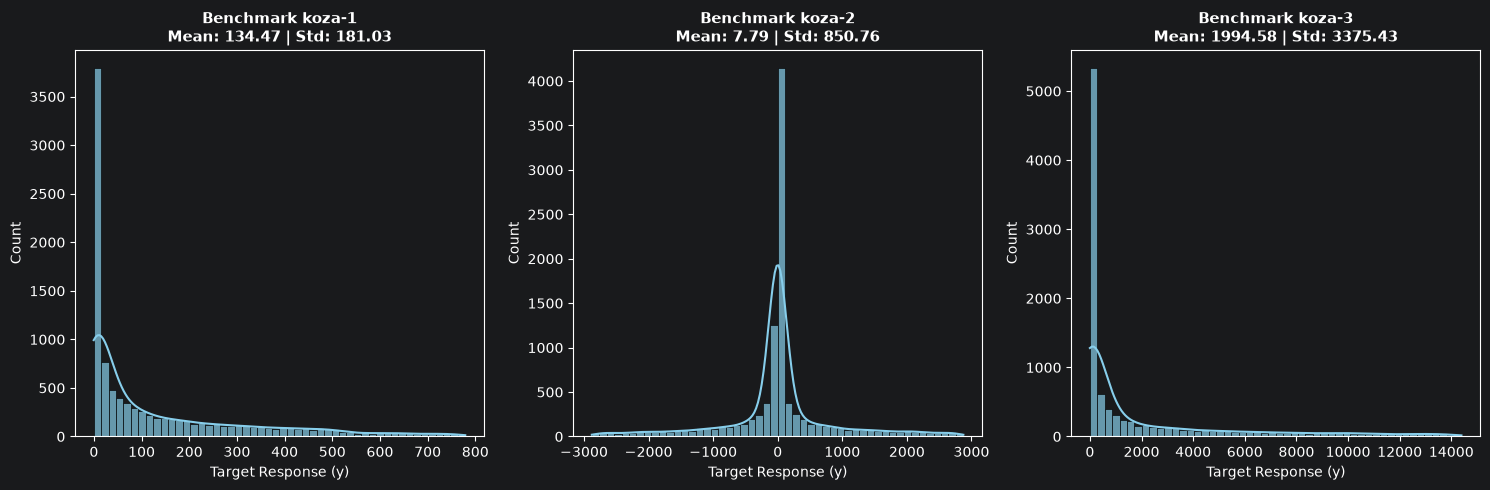

In [7]:
def plot_all_benchmarks_histogram(n_samples=10000, random_state=42, benchmarks = []):
    """
    Plots a 2x3 grid of histograms showing target distributions across all benchmark functions.
    """
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for idx, b_name in enumerate(benchmarks):
        X_tr, y_tr, _, _ = get_benchmark_dataset(b_name, n_train=n_samples, random_state=random_state)

        # Clip extreme asymptote values for H1/F16 (tan x) so outliers don't flatten the plot
        if b_name == 'H1':
            y_display = np.clip(y_tr, -100, 100)
            title_suffix = " (Clipped [-100, 100])"
        else:
            y_display = y_tr
            title_suffix = ""

        ax = axes[idx]
        sns.histplot(y_display, bins=50, kde=True, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)

        # Summary stats in title
        ax.set_title(
            f"Benchmark {b_name}{title_suffix}\nMean: {np.mean(y_tr):.2f} | Std: {np.std(y_tr):.2f}",
            fontsize=11,
            fontweight='bold'
        )
        ax.set_xlabel("Target Response (y)")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Run combined plotting function
plot_all_benchmarks_histogram(benchmarks=benchmarks)

In [8]:
# Training Settings
# Calculate MAE
def print_result():
    train_r2 = r2_score(y_train, est_gp.predict(X_train))
    test_r2  = r2_score(y_test, est_gp.predict(X_test))
    print(f"Train R2 = {train_r2:.6f}")
    print(f"Test R2  = {test_r2:.6f}")


def get_params(random_seed):
    return dict(
    population_size=500,
    generations=200,
    stopping_criteria=0.95,
    tournament_size= 20,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    parsimony_coefficient=0.01,
    random_state=random_seed,
    metric='rmse',
    n_elites=1,

    # predator_population_size= 20,
    #   catch_penalty= 1.00,
    #   catch_num= 1,
    #   catch_size= 10
)

master_rng = np.random.default_rng(seed=42)
random_seeds = master_rng.integers(low=0, high=10000, size=4).tolist()
print(f"Random Seeds = {random_seeds}")
# random_seeds = [0]

Random Seeds = [892, 7739, 6545, 4388]


In [9]:
results = []
trained_regressors = defaultdict(dict)

for seed in random_seeds:
    print(f"\n==================== SEED {seed} ====================")

    for name in benchmarks:
        # 1. Load dataset using the current seed
        X_train, y_train, X_test, y_test = get_benchmark_dataset(name, random_state=seed)

        # 2. Instantiate GP with current random_state
        est_gp = SymbolicRegressor(**get_params(seed))
        print(f"\n====================================================================================")
        print(f"Benchmark Running = {name}")

        # 3. Train GP
        print(f"Benchmark: {name}")
        est_gp.fit(X_train, y_train)

        # 4. Predict and clean numerical issues
        y_pred = est_gp.predict(X_test)
        y_pred = np.nan_to_num(y_pred, nan=0.0, posinf=1e5, neginf=-1e5)

        # 5. Calculate Test R2
        r2 = r2_score(y_test, y_pred)

        # 6. Record findings
        trained_regressors[name][seed] = est_gp
        results.append({
            'Seed': seed,
            'Benchmark': name,
            'R2_Score': r2,
            'Formula': str(est_gp._program)
        })


==================== SEED 892 ====================

Benchmark Running = koza-1
Benchmark: koza-1
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    28.74          17858.7       27          179.373           369.38      3.27m
   1     4.99          208.721        9          167.356          424.907     59.27s
   2     3.65          419.117        5          169.686              415     51.81s
   3     3.51          213.233        1          168.417          423.361     55.44s
   4     3.20          208.362        3          162.172          397.111     52.03s
   5     2.44          206.255        3          162.172          397.111     41.52s
   6     2.61          202.859        3          161.969          397.857      1.08m
   7     2.83          203.258        3          161.969      


--- Summary Performance across seeds ---
  Benchmark      mean       std
0    koza-1  0.999359  0.000723
1    koza-2  0.558780  0.083213
2    koza-3 -0.342638  0.041741


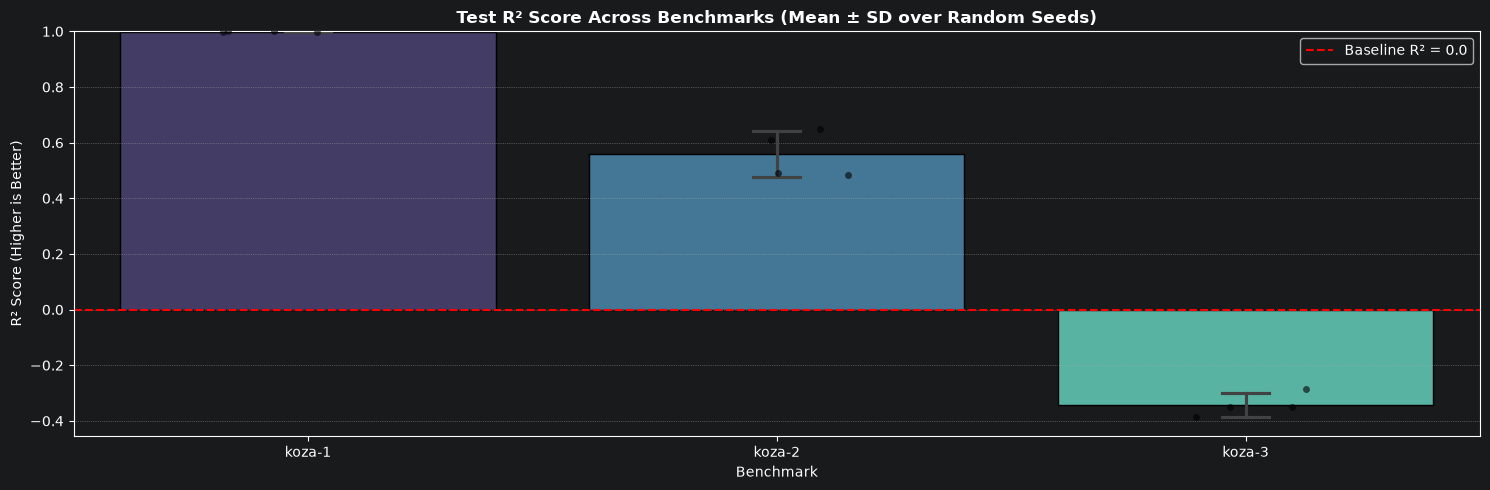

In [10]:
# Convert results into a DataFrame
df_results = pd.DataFrame(results)

# Display summary table with mean and standard deviation across seeds
df_summary = df_results.groupby('Benchmark')['R2_Score'].agg(['mean', 'std']).reset_index()
print("\n--- Summary Performance across seeds ---")
print(df_summary)

# Plot Bar Chart comparison across benchmarks with error bars (representing variability across seeds)
plt.figure(figsize=(15, 5))
sns.barplot(
    data=df_results,
    x='Benchmark',
    y='R2_Score',
    hue='Benchmark',
    palette='mako',
    errorbar='sd',       # Shows standard deviation across seeds
    capsize=0.1,         # Adds caps to error bars
    legend=False,
    edgecolor='black'
)

# Overlay individual seed points
sns.stripplot(
    data=df_results,
    x='Benchmark',
    y='R2_Score',
    color='black',
    alpha=0.6,
    jitter=0.2,
    size=5
)

plt.axhline(0, color='red', linestyle='--', label='Baseline R² = 0.0')
plt.ylim(top=1)
plt.title('Test R² Score Across Benchmarks (Mean ± SD over Random Seeds)', fontsize=12, fontweight='bold')
plt.ylabel('R² Score (Higher is Better)')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

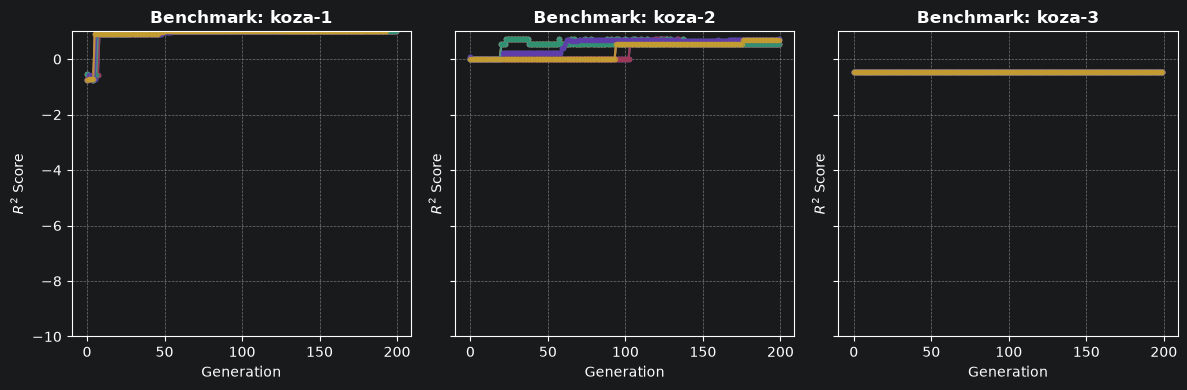

In [11]:
# Plot Best Program per Generation (R2 Score)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharey=True)
axes = axes.flatten()

# Iterate through each benchmark
for idx, (name, seed_dict) in enumerate(trained_regressors.items()):
    for seed, est_gp in seed_dict.items():
        ax = axes[idx]

        # Fetch test data ONCE per benchmark
        _, _, X_test, y_test = get_benchmark_dataset(name, random_state=0)

        # Plot each seed as a separate line in the current benchmark's subplot
        for seed, est_gp in seed_dict.items():
            r2_scores = []
            for program in est_gp.best_programs_per_gen:
                y_pred = program.execute(X_test) #[cite: 2]
                score = r2_score(y_test, y_pred)
                r2_scores.append(score)

            # Plot line for this specific seed
            ax.plot(
                range(len(r2_scores)),
                r2_scores,
                marker='o',
                markersize=3,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha=0.75
            )

        # Subplot formatting per benchmark
        ax.set_title(f'Benchmark: {name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel('$R^2$ Score')
        ax.set_ylim(-10, 1)  # Set limit on each axis object
        ax.grid(True, linestyle='--', alpha=0.6)
        # ax.legend(loc='lower right', fontsize=8)

# Hide any remaining unused subplots in the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

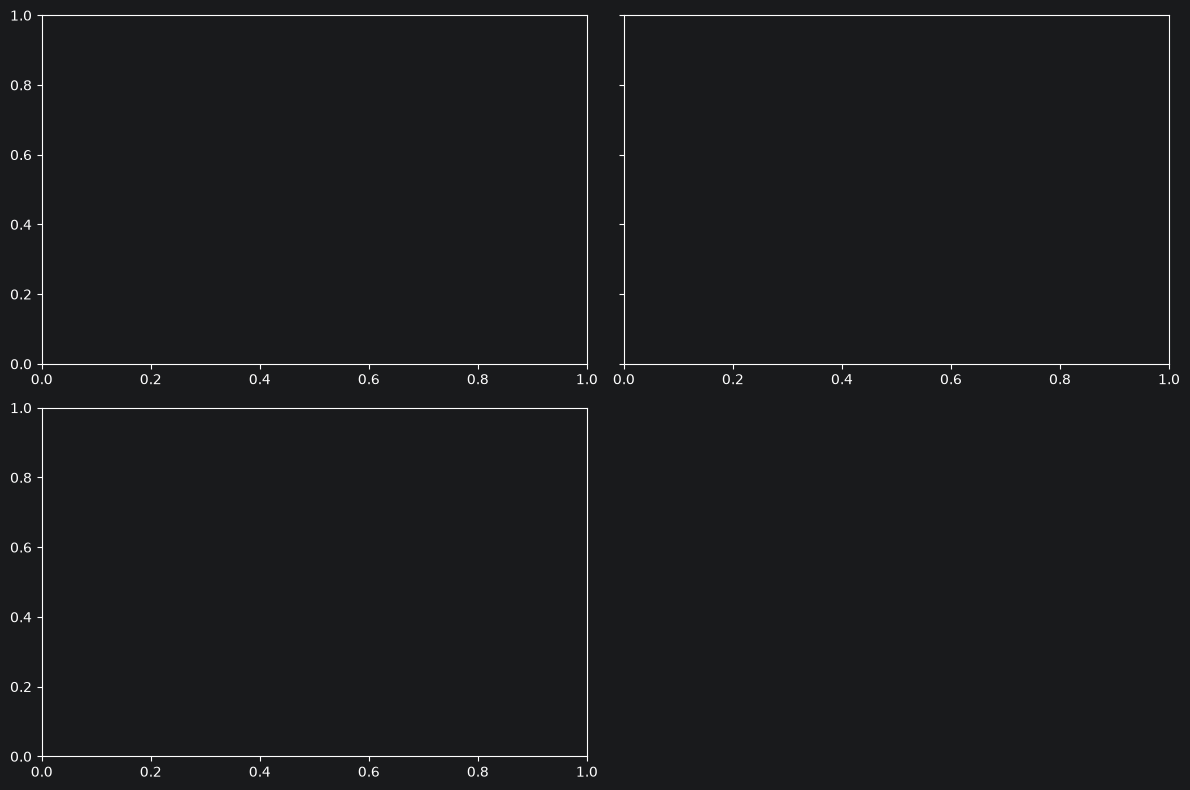

In [17]:
# Plot Average Fitness Graph

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharey=True)
axes = axes.flatten()

def rmse_to_r2(rmse, y_true):
    """Convert RMSE to R2 score using target standard deviation."""
    # Calculate sample variance of actual y values (ddof=1)
    var_y = np.var(y_true, ddof=1)

    if var_y == 0:
        return 0.0  # Avoid division by zero when target has zero variance

    return 1.0 - (rmse ** 2 / var_y)

# Iterate through each benchmark
for idx, (name, seed_dict) in enumerate(trained_regressors.items()):
    for seed, est_gp in seed_dict.items():
        ax = axes[idx]

        # Fetch test data ONCE per benchmark
        _, _, X_test, y_test = get_benchmark_dataset(name, random_state=0)

        # Plot each seed as a separate line in the current benchmark's subplot
        average_fitness = np.array(est_gp.run_details_["average_fitness"])

        var_y = np.var(y_train)

        # 3. Convert fitness to R2 based on your loss metric
        metric_name = getattr(est_gp.metric, "name", est_gp.metric)
        if metric_name in ["mse", "mean square error"]:
            r2_scores = 1.0 - (average_fitness / var_y)
        elif metric_name in ["rmse", "root mean square error"]:
            r2_scores = 1.0 - ((average_fitness**2) / var_y)
        elif metric_name in ["r2", "r2 score"]:
            r2_scores = average_fitness
        else:
            raise ValueError(f"Cannot directly convert metric '{metric_name}' to R2.")

        # Convert numpy array back to list if needed
        r2_scores = r2_scores.tolist()

        # Plot line for this specific seed
        ax.plot(
            range(len(r2_scores)),
            r2_scores,
            marker='o',
            markersize=0,
            linewidth=1.5,
            label=f'Seed {seed}',
            alpha=0.75
        )

        # Subplot formatting per benchmark
        ax.set_title(f'Benchmark: {name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel('$R^2$ Score')
        ax.set_ylim(-2, 2)  # Set limit on each axis object
        ax.grid(True, linestyle='--', alpha=0.6)
        # ax.legend(loc='lower right', fontsize=8)

# Hide any remaining unused subplots in the grid
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

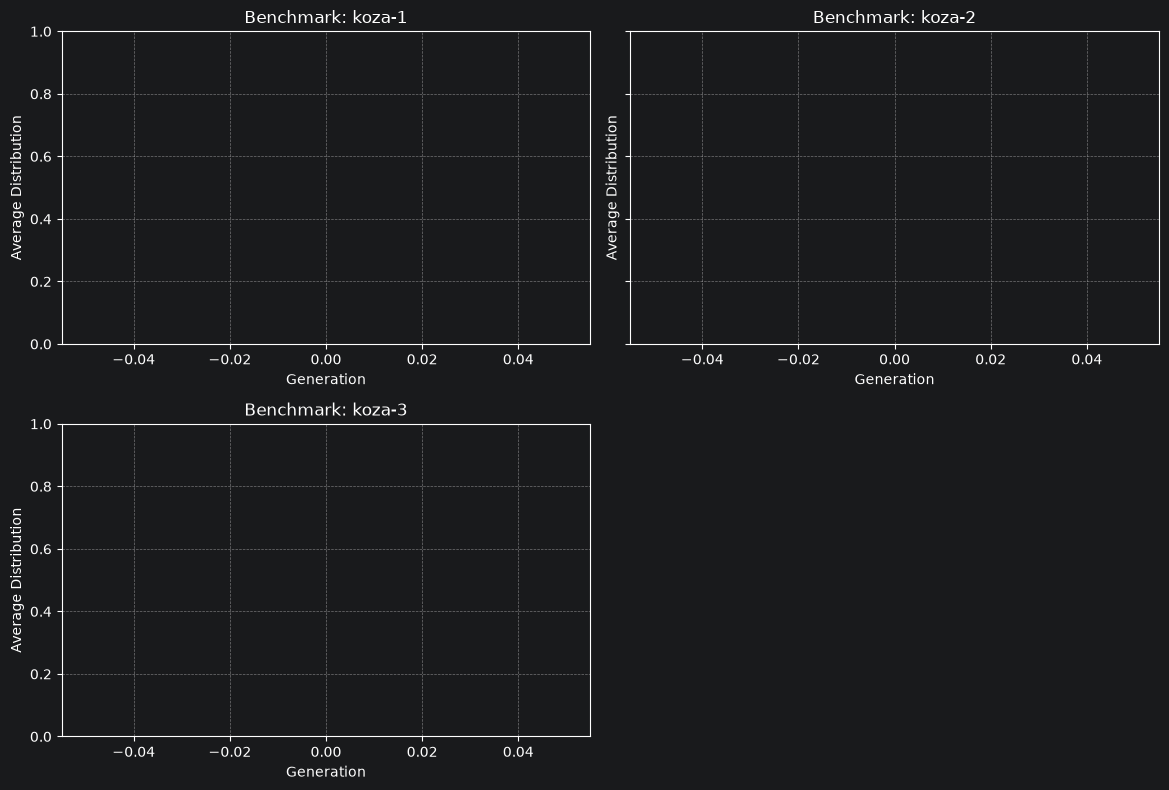

In [12]:
num_models = len(benchmarks)
cols = 2
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharey=True)
axes = axes.flatten()  # Flatten to iterate easily

# 2. Iterate through each benchmark regressor
for idx, (name, seed_dict) in enumerate(trained_regressors.items()):
    for seed, est_gp in seed_dict.items():
        # Access name, seed, and est_gp here
        # print(f"Benchmark: {name}, Seed: {seed}, Model: {est_gp}")
        # Fetch test data for the benchmark
        _, _, X_test, y_test = get_benchmark_dataset(name, random_state=0)

        # Compute R2 score progression
        distributions = []
        for gen_distribution in est_gp.population_distribution:
            distributions.append(gen_distribution)

        # Plot in designated subplot
        ax = axes[idx]
        ax.plot(range(len(distributions)), distributions, marker='o', markersize=4, linewidth=1.5, label=name, alpha=0.75)
        ax.set_title(f'Benchmark: {name}', fontsize=12)
        ax.set_xlabel('Generation')
        ax.set_ylabel('Average Distribution')
        ax.grid(True, linestyle='--', alpha=0.6)
        # ax.legend()

# Hide unused subplots if num_models is odd
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.ylim(0, 1)
plt.show()

In [13]:
# results = []
# trained_regressors = {}
#
# for name in benchmarks:
#     # 1. Load dataset
#     X_train, y_train, X_test, y_test = get_benchmark_dataset(name, random_state=0)
#
#     # 2. Train GP using MAE for stable evolution
#     est_gp = SymbolicRegressor(**gp_params)
#     print(f"\n====================================================================================")
#     print(f"Benchmark Running = {name}")
#     est_gp.fit(X_train, y_train)
#     trained_regressors[name] = est_gp
#     print_result()
#
#     # 3. Predict and handle potential numerical asymptote spikes
#     y_pred = est_gp.predict(X_test)
#     y_pred = np.nan_to_num(y_pred, nan=0.0, posinf=1e5, neginf=-1e5)
#
#     # 4. Calculate Test R2
#     r2 = r2_score(y_test, y_pred)
#
#     # 5. Record findings
#     results.append({
#         'Benchmark': name,
#         'R2_Score': r2,
#         'Formula': str(est_gp._program)
#     })
#
#
# # Convert results into a DataFrame
# df_results = pd.DataFrame(results)
# print(df_results[['Benchmark', 'R2_Score', 'Formula']])
#
# # Plot Bar Chart comparison across benchmarks
# plt.figure(figsize=(15, 5))
# sns.barplot(
#     data=df_results,
#     x='Benchmark',
#     y='R2_Score',
#     hue='Benchmark',
#     palette='mako',
#     legend=False,
#     edgecolor='black'
# )
# plt.axhline(0, color='red', linestyle='--', label='Baseline R² = 0.0')
# plt.ylim(-1.0, 1.05)  # Set limits for clear visualization
# plt.title('Test R² Score Comparison Across Benchmarks', fontsize=12, fontweight='bold')
# plt.ylabel('R² Score (Higher is Better)')
# plt.grid(axis='y', linestyle=':', alpha=0.7)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [14]:
# num_models = len(trained_regressors)
# cols = 2
# # rows = math.ceil(total_run / cols)
# rows = math.ceil(num_models / cols)
#
# fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharey=True)
# axes = axes.flatten()  # Flatten to iterate easily
#
# # 2. Iterate through each benchmark regressor
# for idx, (name, est_gp) in enumerate(trained_regressors.items()):
#     # Fetch test data for the benchmark
#     _, _, X_test, y_test = get_benchmark_dataset(name, random_state=0)
#
#     # Compute R2 score progression
#     r2_scores = []
#     for program in est_gp.best_programs_per_gen:
#         y_pred = program.execute(X_test)
#         score = r2_score(y_test, y_pred)
#         r2_scores.append(score)
#
#     # Plot in designated subplot
#     ax = axes[idx]
#     ax.plot(range(len(r2_scores)), r2_scores, marker='o', linewidth=2, label=name)
#     ax.set_title(f'Benchmark: {name}', fontsize=12)
#     ax.set_xlabel('Generation')
#     ax.set_ylabel('$R^2$ Score')
#     ax.grid(True, linestyle='--', alpha=0.6)
#     ax.legend()
#
# # Hide unused subplots if num_models is odd
# for j in range(idx + 1, len(axes)):
#     fig.delaxes(axes[j])
#
# plt.tight_layout()
# plt.ylim(-1, 1)
# plt.show()

In [15]:
# Testing Similarity
#
# from gplearn.fitness import _Fitness
# from gplearn.functions import add2, sub2, mul2, div2
# from gplearn._program import _Program
#
# # 1. Define hyperparameters
# const_range = (-1.0, 1.0)
# init_depth = (2, 6)
# init_method = 'half and half'
# p_point_replace = 0.05
# parsimony_coefficient = 0.001
# n_features = 3  # Must be an integer (e.g., X0, X1, X2)
#
# # 2. Use real _Function objects from gplearn
# function_set = (add2, sub2, mul2, div2)
#
# arities = {}
# for function in function_set:
#     arity = function.arity
#     arities[arity] = arities.get(arity, [])
#     arities[arity].append(function)
#
# # 3. Supply a dummy/real _Fitness object for metric
# dummy_metric = _Fitness(function=lambda y, y_pred, w: np.mean(np.abs(y - y_pred)), greater_is_better=True)
#
# # 4. Supply a valid RandomState instance
# random_state = np.random.RandomState(42)
#
# # Instantiate _Program
# prog1 = _Program(
#     function_set=function_set,
#     arities=arities,
#     init_depth=init_depth,
#     init_method=init_method,
#     n_features=n_features,
#     metric=dummy_metric,
#     transformer=None,
#     const_range=const_range,
#     p_point_replace=p_point_replace,
#     parsimony_coefficient=parsimony_coefficient,
#     feature_names=None,
#     random_state=random_state,
#     program=None
# )
#
# prog2 = _Program(
#     function_set=function_set,
#     arities=arities,
#     init_depth=init_depth,
#     init_method=init_method,
#     n_features=n_features,
#     metric=dummy_metric,
#     transformer=None,
#     const_range=const_range,
#     p_point_replace=p_point_replace,
#     parsimony_coefficient=parsimony_coefficient,
#     feature_names=None,
#     random_state=random_state,
#     program=None
# )
#
# # Call string execution properly
# print(f"Prog1 = {str(prog1)}")
# print(f"Prog2 = {str(prog2)}")
# print(f"Similarity = {prog2.calculate_similarity(prog1)}")
# print(f"Distance   = {prog1.distance(prog2, constant= 2)}")